# Spotify Music Analytics & Recommendation System

### Solution Engineering – Python

This notebook presents the current state of our Spotify project.

The goal is to clean and understand the Spotify dataset before using it for feature engineering and recommendation tasks.

# 1. Raw Data Sources

The project started with several Spotify datasets obtained from different sources.

Each dataset provides a different perspective on the music collection.

| Dataset | Purpose |
|----------|----------|
| Tracks | Song metadata and popularity |
| Artists | Artist information and genres |
| Albums | Album-level metadata |
| Audio Features | Musical characteristics (energy, danceability, valence, etc.) |
| Lyrics Features | Linguistic and readability measures |

In [1]:
from pathlib import Path
import sys
import warnings

import duckdb
import pandas as pd

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from config.paths import DUCKDB_PATH

con = duckdb.connect(DUCKDB_PATH)

In [2]:
raw_summary = pd.DataFrame({
    "Table": [
        "tracks",
        "artists",
        "albums",
        "audio_features",
        "lyrics_features"
    ],
    "Rows": [
        con.execute("SELECT COUNT(*) FROM tracks").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM artists").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM albums").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM audio_features").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM lyrics_features").fetchone()[0]
    ]
})

raw_summary

,Table,Rows
0,tracks,101939
1,artists,56129
2,albums,75511
3,audio_features,101909
4,lyrics_features,94954


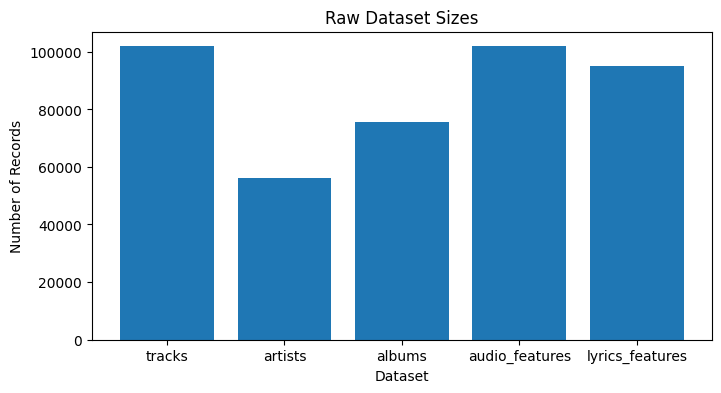

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.bar(
    raw_summary["Table"],
    raw_summary["Rows"]
)

plt.title("Raw Dataset Sizes")
plt.ylabel("Number of Records")
plt.xlabel("Dataset")

plt.show()

### Initial Observation

The datasets originate from different Spotify sources and therefore vary considerably in size and coverage.

Before any analysis could be performed, the data had to be validated, cleaned, and standardized.

# 2. Why Cleaning Was Necessary

Before performing any analysis, the raw Spotify data was examined for quality issues.

Several problems were identified that could negatively affect analysis results and recommendation quality:

- Non-musical content was mixed with songs
- Lyrics were not available for all tracks
- Dataset coverage differed substantially across sources
- Duplicate and inconsistent records were present

The following examples illustrate these challenges.

In [4]:
tracks_raw = con.execute("SELECT * FROM tracks").df()
artists_raw = con.execute("SELECT * FROM artists").df()
albums_raw = con.execute("SELECT * FROM albums").df()
audio_features_raw = con.execute("SELECT * FROM audio_features").df()
lyrics_features_raw = con.execute("SELECT * FROM lyrics_features").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## 2.1 Non-Music Content

Some records were not actual songs, but podcasts, audiobooks, sleep sounds, meditation tracks, or spoken-word content.

These records had to be filtered because they would distort music-based analysis and recommendations.

In [5]:
non_music_pattern = (
    "podcast|episode|audiobook|audio book|meditation|sleep|rain sounds|"
    "white noise|brown noise|guided|story|stories|chapter|interview|talk"
)

non_music_examples = tracks_raw.loc[
    tracks_raw["name"].str.contains(non_music_pattern, case=False, na=False),
    ["id", "name", "popularity"]
].drop_duplicates().head(15)

non_music_examples

,id,name,popularity
29,6bNFUbqg3cJRgIBsypY29x,The Ketchup Story,43.0
31,490afAlqNYXTwEonFlhg7V,The Story of Alice and the White Rabbit / The ...,20.0
48,4iuLMS9ANTpUSW0g13q3ow,The Child's Story by Charles Dickens,7.0
165,6RjEYuN17uK9zKx0I51xpd,Get Some Sleep,33.0
215,3OtZb0PdIsIM6EqCbMQY65,Sleep Talker,26.0
389,5uOvMs36GwI49MH2bWG967,Envelopes (Chapter VI),40.0
489,5U6DLtwaVFcggOzMjimZ5g,Interview With Writer Jeffrey Bays,4.0
531,27QbQb7cRHT5LJqbc7NHVK,Talk It Out - Live,21.0
698,3iPjXKZENaAem0eT7hncmO,God Is Not Sleeping,16.0
862,3qAePP1MIOkrwDCn4MraiU,Sleep,23.0


In [6]:
non_music_counts = {}

for keyword in [
    "podcast", "episode", "audiobook", "meditation", 
    "sleep", "white noise", "rain sounds", "chapter"
]:
    non_music_counts[keyword] = tracks_raw["name"].str.contains(
        keyword, case=False, na=False
    ).sum()

non_music_counts = pd.DataFrame({
    "Keyword": non_music_counts.keys(),
    "Matches": non_music_counts.values()
}).sort_values("Matches", ascending=False)

non_music_counts

,Keyword,Matches
7,chapter,513
4,sleep,260
6,rain sounds,107
3,meditation,43
5,white noise,37
1,episode,22
0,podcast,1
2,audiobook,0


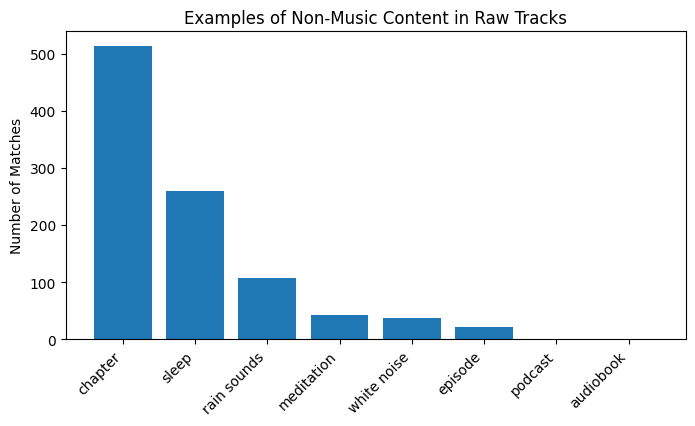

In [7]:
plt.figure(figsize=(8,4))

plt.bar(
    non_music_counts["Keyword"],
    non_music_counts["Matches"]
)

plt.title("Examples of Non-Music Content in Raw Tracks")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45, ha="right")

plt.show()

## 2.2 Lyrics Availability

Lyrics features were important for text-based analysis.

However, missing lyrics were stored with `-1` placeholder values, so the raw row count overestimates usable lyrics coverage.

In [8]:
lyrics_cols = [
    col for col in lyrics_features_raw.columns
    if col not in ["track_id", "id"]
]

invalid_lyrics_mask = (
    lyrics_features_raw[lyrics_cols]
    .eq(-1)
    .any(axis=1)
)

valid_lyrics_raw = lyrics_features_raw.loc[~invalid_lyrics_mask].copy()

lyrics_available_raw = valid_lyrics_raw["track_id"].nunique()
total_tracks_raw = tracks_raw["id"].nunique()
lyrics_missing_or_invalid_raw = total_tracks_raw - lyrics_available_raw

lyrics_status_raw = pd.DataFrame({
    "Status": ["Valid Lyrics", "Missing / Invalid Lyrics"],
    "Tracks": [lyrics_available_raw, lyrics_missing_or_invalid_raw]
})

lyrics_status_raw

,Status,Tracks
0,Valid Lyrics,79420
1,Missing / Invalid Lyrics,22519


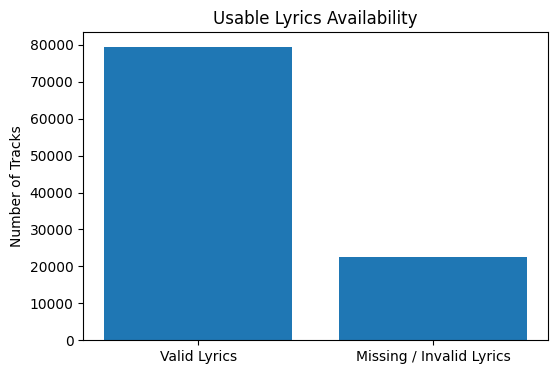

In [9]:
plt.figure(figsize=(6,4))

plt.bar(
    lyrics_status_raw["Status"],
    lyrics_status_raw["Tracks"]
)

plt.title("Usable Lyrics Availability")
plt.ylabel("Number of Tracks")

plt.show()

## 2.3 Dataset Coverage

The datasets do not cover the same set of tracks.

This matters because later analyses depend on which features are available for each track.

In [10]:
raw_coverage = pd.DataFrame({
    "Dataset": [
        "Artists",
        "Albums",
        "Audio Features",
        "Valid Lyrics Features"
    ],
    "Coverage (%)": [
        artists_raw["track_id"].nunique() / tracks_raw["id"].nunique() * 100,
        albums_raw["track_id"].nunique() / tracks_raw["id"].nunique() * 100,
        audio_features_raw["track_id"].nunique() / tracks_raw["id"].nunique() * 100,
        valid_lyrics_raw["track_id"].nunique() / tracks_raw["id"].nunique() * 100
    ]
})

raw_coverage

,Dataset,Coverage (%)
0,Artists,44.041044
1,Albums,74.074692
2,Audio Features,99.970571
3,Valid Lyrics Features,77.909338


In [19]:
linkage = pd.DataFrame({
    "Dataset": [
        "Artists",
        "Albums",
        "Audio Features",
        "Valid Lyrics"
    ],
    "Tracks Linked (%)": [
        tracks_raw["id"].isin(artists_raw["track_id"]).mean() * 100,
        tracks_raw["id"].isin(albums_raw["track_id"]).mean() * 100,
        tracks_raw["id"].isin(audio_features_raw["track_id"]).mean() * 100,
        tracks_raw["id"].isin(valid_lyrics_raw["track_id"]).mean() * 100
    ]
})

linkage

,Dataset,Tracks Linked (%)
0,Artists,44.038101
1,Albums,74.065863
2,Audio Features,99.970571
3,Valid Lyrics,77.909338


In [20]:
all_sources = (
    tracks_raw["id"].isin(artists_raw["track_id"])
    & tracks_raw["id"].isin(albums_raw["track_id"])
    & tracks_raw["id"].isin(audio_features_raw["track_id"])
    & tracks_raw["id"].isin(valid_lyrics_raw["track_id"])
)

print(
    f"Tracks with ALL sources available: "
    f"{all_sources.mean()*100:.2f}%"
)

Tracks with ALL sources available: 30.65%


In [21]:
artist_lyrics = (
    tracks_raw["id"].isin(artists_raw["track_id"])
    & tracks_raw["id"].isin(valid_lyrics_raw["track_id"])
)

album_lyrics = (
    tracks_raw["id"].isin(albums_raw["track_id"])
    & tracks_raw["id"].isin(valid_lyrics_raw["track_id"])
)

print(f"Artist + Lyrics: {artist_lyrics.mean()*100:.2f}%")
print(f"Album + Lyrics: {album_lyrics.mean()*100:.2f}%")

Artist + Lyrics: 32.27%
Album + Lyrics: 56.78%


### Key Observation

While audio features are available for nearly all tracks, only 30.65% of tracks can be enriched with information from all available datasets simultaneously.

This influenced our later feature engineering decisions and motivated the use of audio features as the primary recommendation signal.

# 3. Cleaning Approach

After identifying the major quality issues, a cleaning pipeline was developed to improve data quality and consistency.

The following cleaning steps were applied to improve data quality:

- **Duplicate records:** Removed duplicate entries
- **Non-music content:** Filtered podcasts, audiobooks, and similar content where possible
- **Invalid lyrics:** Removed records containing placeholder values (`-1`)
- **Dataset consistency:** Standardized identifiers and exported cleaned datasets for further analysis

In [12]:
processed_dir = PROJECT_ROOT / "data" / "processed"

tracks_clean = pd.read_parquet(
    processed_dir / "tracks_clean.parquet"
)

artists_clean = pd.read_parquet(
    processed_dir / "artists_clean.parquet"
)

albums_clean = pd.read_parquet(
    processed_dir / "albums_clean.parquet"
)

audio_features_clean = pd.read_parquet(
    processed_dir / "audio_features_clean.parquet"
)

lyrics_clean = pd.read_parquet(
    processed_dir / "lyrics_features_valid_clean.parquet"
)

In [13]:
comparison = pd.DataFrame({
    "Dataset": [
        "Tracks",
        "Artists",
        "Albums",
        "Audio Features",
        "Lyrics Features"
    ],
    "Raw": [
        len(tracks_raw),
        len(artists_raw),
        len(albums_raw),
        len(audio_features_raw),
        len(lyrics_features_raw)
    ],
    "Cleaned": [
        len(tracks_clean),
        len(artists_clean),
        len(albums_clean),
        len(audio_features_clean),
        len(lyrics_clean)
    ]
})

comparison

,Dataset,Raw,Cleaned
0,Tracks,101939,95977
1,Artists,56129,56129
2,Albums,75511,75511
3,Audio Features,101909,95948
4,Lyrics Features,94954,74128


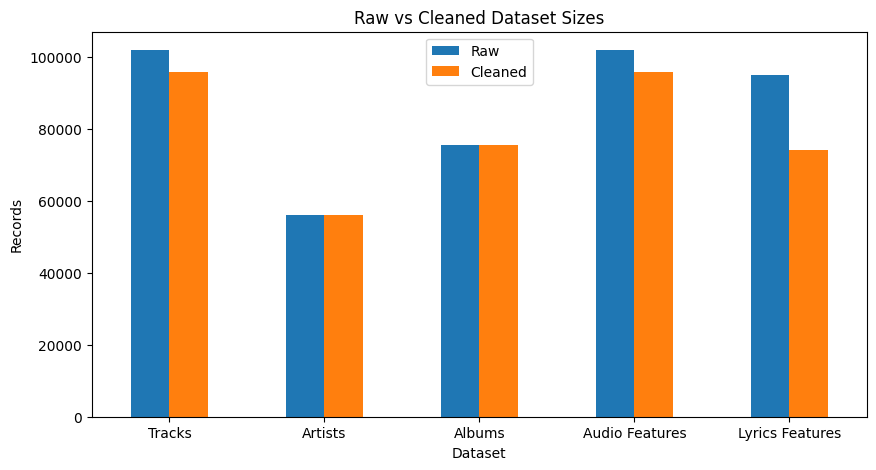

In [14]:
comparison_plot = comparison.set_index("Dataset")

comparison_plot.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Raw vs Cleaned Dataset Sizes")
plt.ylabel("Records")

plt.xticks(rotation=0)

plt.show()

In [15]:
comparison["Removed"] = comparison["Raw"] - comparison["Cleaned"]

comparison[
    ["Dataset", "Removed"]
].sort_values(
    "Removed",
    ascending=False
)

,Dataset,Removed
4,Lyrics Features,20826
0,Tracks,5962
3,Audio Features,5961
1,Artists,0
2,Albums,0


### Coverage After Cleaning

Although the datasets differ in coverage, the cleaned data retains strong support for most analytical tasks.

Audio features remain available for nearly all tracks, while lyrics and album information cover a substantial portion of the collection.

In [16]:
coverage = pd.DataFrame({
    "Dataset": [
        "Artists",
        "Albums",
        "Audio Features",
        "Lyrics Features"
    ],
    "Coverage (%)": [
        artists_clean["track_id"].nunique() / tracks_clean["id"].nunique() * 100,
        albums_clean["track_id"].nunique() / tracks_clean["id"].nunique() * 100,
        audio_features_clean["track_id"].nunique() / tracks_clean["id"].nunique() * 100,
        lyrics_clean["track_id"].nunique() / tracks_clean["id"].nunique() * 100
    ]
})

coverage

,Dataset,Coverage (%)
0,Artists,46.776832
1,Albums,78.676141
2,Audio Features,99.969784
3,Lyrics Features,77.235171


### Key Observations

- The largest reduction occurred in the lyrics dataset, with over **20,000 records removed** due to missing or invalid lyric information.
- Approximately **6,000 tracks** were removed during cleaning, primarily due to duplicate records, non-musical content, and data quality issues.
- The audio features dataset was reduced by a similar amount because it is directly linked to the remaining valid tracks.
- Artist and album datasets required little to no record removal, indicating higher overall consistency in these sources.
- After cleaning, the project retained nearly **96,000 tracks**, providing a large and reliable foundation for exploratory analysis and feature engineering.

# 4. Exploratory Data Analysis

## 4.1 Dataset Composition

After cleaning, we first examined what kind of music is represented in the dataset.

This section focuses on:

- most common genres
- most popular artists
- track popularity
- release years

### Most Common Genres

Genres are stored in the artist dataset.

Because one artist can have multiple genres, the genre lists were expanded before counting the most frequent genres.

In [17]:
import ast

artists_genres = artists_clean.copy()

def parse_genres(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass
        return [value]
    return []

artists_genres["genre_list"] = artists_genres["genres"].apply(parse_genres)

top_genres = (
    artists_genres
    .explode("genre_list")
    .dropna(subset=["genre_list"])
)

top_genres = top_genres[
    top_genres["genre_list"].astype(str).str.strip() != ""
]

top_genres_count = (
    top_genres["genre_list"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_genres_count.columns = ["Genre", "Count"]

top_genres_count

,Genre,Count
0,pop,543
1,dance pop,485
2,rock,431
3,folk-pop,402
4,pop rap,387
5,modern rock,386
6,edm,375
7,electro house,362
8,latin rock,335
9,indie rock,334


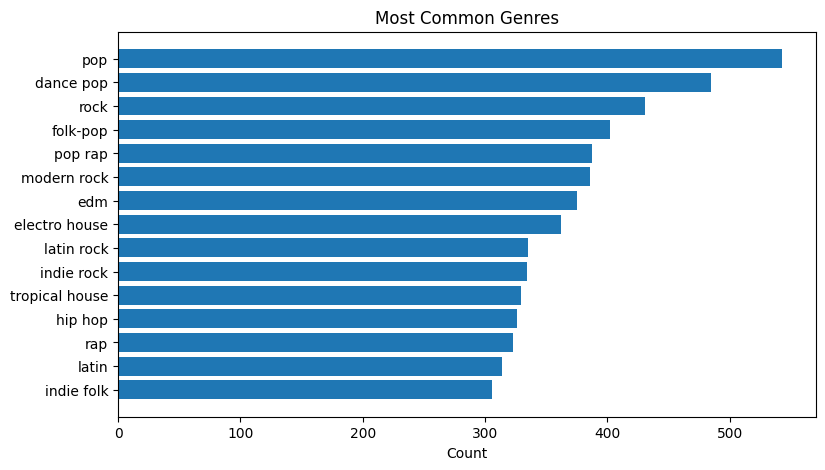

In [18]:
plt.figure(figsize=(9,5))

plt.barh(
    top_genres_count["Genre"][::-1],
    top_genres_count["Count"][::-1]
)

plt.title("Most Common Genres")
plt.xlabel("Count")

plt.show()

### Most Popular Artists

Artist popularity was analyzed using the cleaned artist dataset.

To avoid repeated artists appearing multiple times, artists were grouped by name and their maximum popularity score was used.

In [19]:
top_artists = (
    artists_clean
    .dropna(subset=["name", "artist_popularity"])
    .groupby("name", as_index=False)["artist_popularity"]
    .max()
    .sort_values("artist_popularity", ascending=False)
    .head(15)
)

top_artists

,name,artist_popularity
3559,Ariana Grande,100
13384,Drake,98
39772,Post Malone,96
24861,Juice WRLD,95
26352,Khalid,95
53594,XXXTENTACION,95
37929,Ozuna,95
3372,Anuel Aa,94
50975,Travis Scott,94
40238,Queen,94


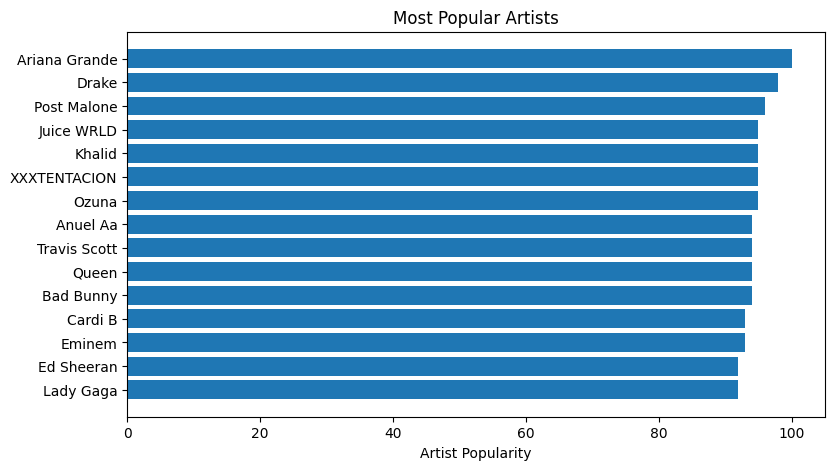

In [20]:
plt.figure(figsize=(9,5))

plt.barh(
    top_artists["name"][::-1],
    top_artists["artist_popularity"][::-1]
)

plt.title("Most Popular Artists")
plt.xlabel("Artist Popularity")

plt.show()

### Track Popularity Distribution

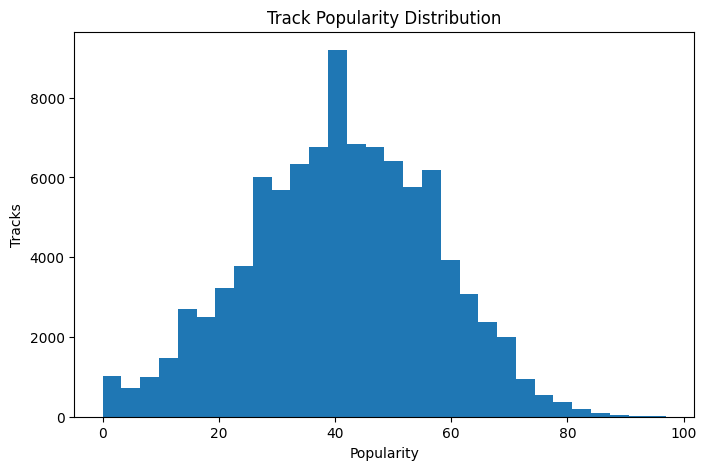

In [21]:
plt.figure(figsize=(8,5))

plt.hist(
    tracks_clean["popularity"],
    bins=30
)

plt.title("Track Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Tracks")

plt.show()

## 4.2 Audio Feature Analysis

The cleaned track dataset contains Spotify audio descriptors such as danceability, energy, valence, acousticness, and tempo.

These variables describe the general musical mood and structure of the tracks.

In [22]:
spotify_audio_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "tempo"
]

tracks_audio = tracks_clean[spotify_audio_features].copy()

tracks_audio.head()

,danceability,energy,valence,acousticness,tempo
0,0.698,0.606,0.6220,0.294,115.018
1,0.367,0.349,0.1920,0.971,81.850
2,0.748,0.666,0.3590,0.101,114.982
3,0.801,0.610,0.9420,0.109,104.199
4,0.515,0.351,0.0383,0.471,139.926


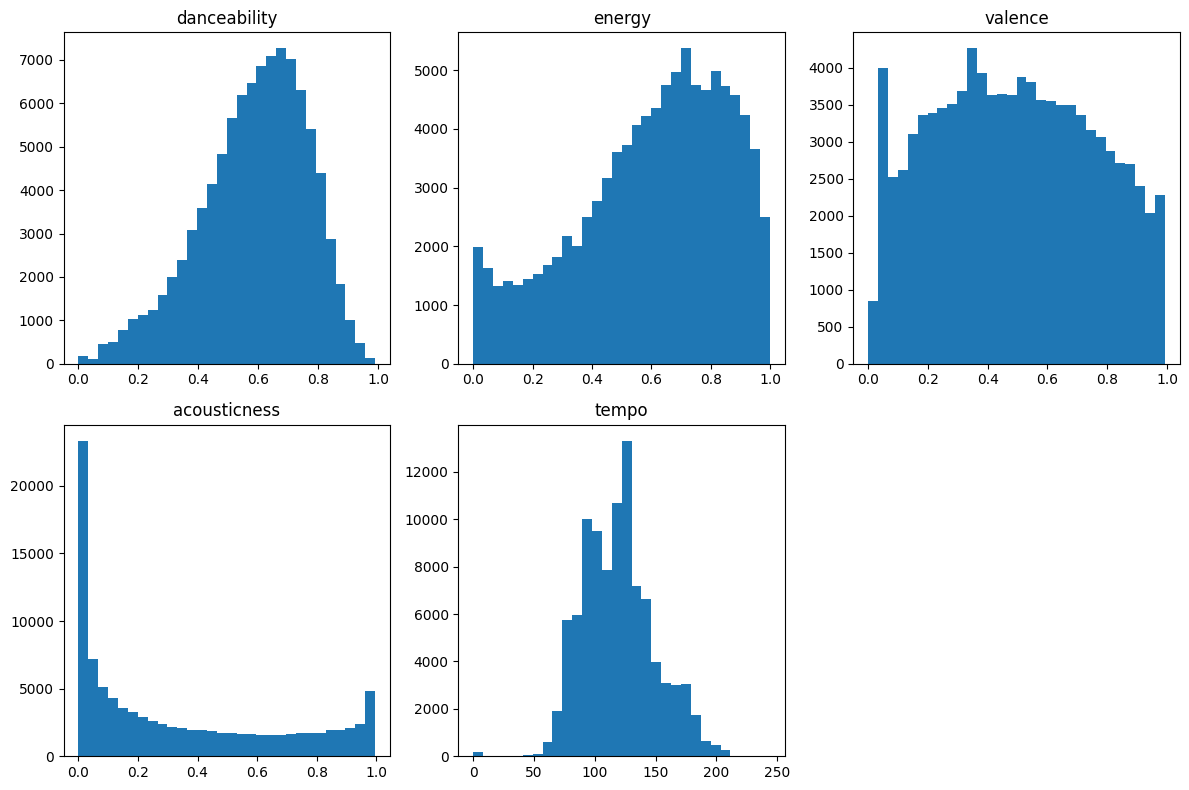

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes = axes.flatten()

for i, feature in enumerate(spotify_audio_features):
    axes[i].hist(
        tracks_audio[feature].dropna(),
        bins=30
    )
    axes[i].set_title(feature)

axes[-1].axis("off")

plt.tight_layout()
plt.show()

### Key Observations

- The dataset contains a broad range of danceability and energy values.
- Valence varies strongly, meaning both positive and darker-sounding tracks are represented.
- Acousticness shows that the collection includes both acoustic and more electronic tracks.
- Tempo varies widely, which is expected across different genres and music styles.

## 4.3 Relationships Between Audio Features

Correlations were examined to understand how the main audio characteristics relate to each other.

In [24]:
spotify_corr_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "liveness",
    "tempo"
]

spotify_corr = tracks_clean[spotify_corr_features].corr()

spotify_corr

,danceability,energy,valence,acousticness,instrumentalness,speechiness,liveness,tempo
danceability,1.000000,0.275275,0.524865,-0.299533,-0.274045,0.172990,-0.081460,-0.006309
energy,0.275275,1.000000,0.411528,-0.740596,-0.292702,0.037560,0.195271,0.214311
valence,0.524865,0.411528,1.000000,-0.259688,-0.316219,0.077838,0.038174,0.109242
acousticness,-0.299533,-0.740596,-0.259688,1.000000,0.242371,0.000063,-0.084454,-0.185981
instrumentalness,-0.274045,-0.292702,-0.316219,0.242371,1.000000,-0.119827,-0.087164,-0.074459
speechiness,0.172990,0.037560,0.077838,0.000063,-0.119827,1.000000,0.127348,0.000915
liveness,-0.081460,0.195271,0.038174,-0.084454,-0.087164,0.127348,1.000000,0.020059
tempo,-0.006309,0.214311,0.109242,-0.185981,-0.074459,0.000915,0.020059,1.000000


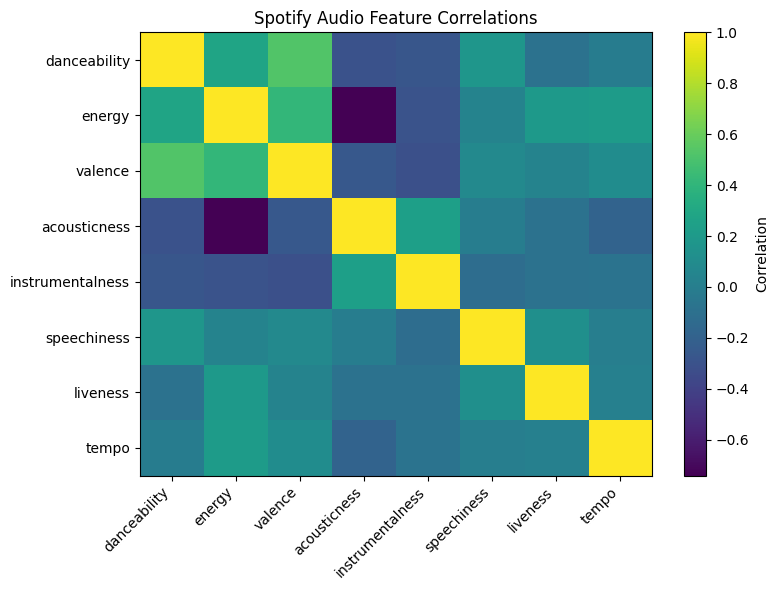

In [25]:
plt.figure(figsize=(8, 6))

plt.imshow(spotify_corr, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(spotify_corr.columns)),
    spotify_corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(spotify_corr.index)),
    spotify_corr.index
)

plt.title("Spotify Audio Feature Correlations")

plt.tight_layout()
plt.show()

### Key Observations

- The dataset is generally skewed toward tracks with moderate to high danceability and energy, indicating a strong presence of contemporary popular music.
- Acousticness shows a highly polarized distribution, suggesting a mixture of highly acoustic recordings and strongly produced electronic or studio tracks.
- The average tempo is approximately 119 BPM, with substantial variation across musical styles.
- Danceability and valence exhibit a moderate positive relationship (r ≈ 0.52), indicating that more danceable songs tend to have a more positive emotional tone.
- The strongest relationship is the negative correlation between energy and acousticness (r ≈ -0.74), reflecting the distinction between acoustic recordings and high-energy produced tracks.

## 5.3 Lyrics Feature Analysis

In addition to Spotify audio features, lyrics were analyzed to capture linguistic characteristics of songs.

The extracted features describe vocabulary usage, sentence structure, and textual complexity, providing an additional perspective beyond purely musical attributes.

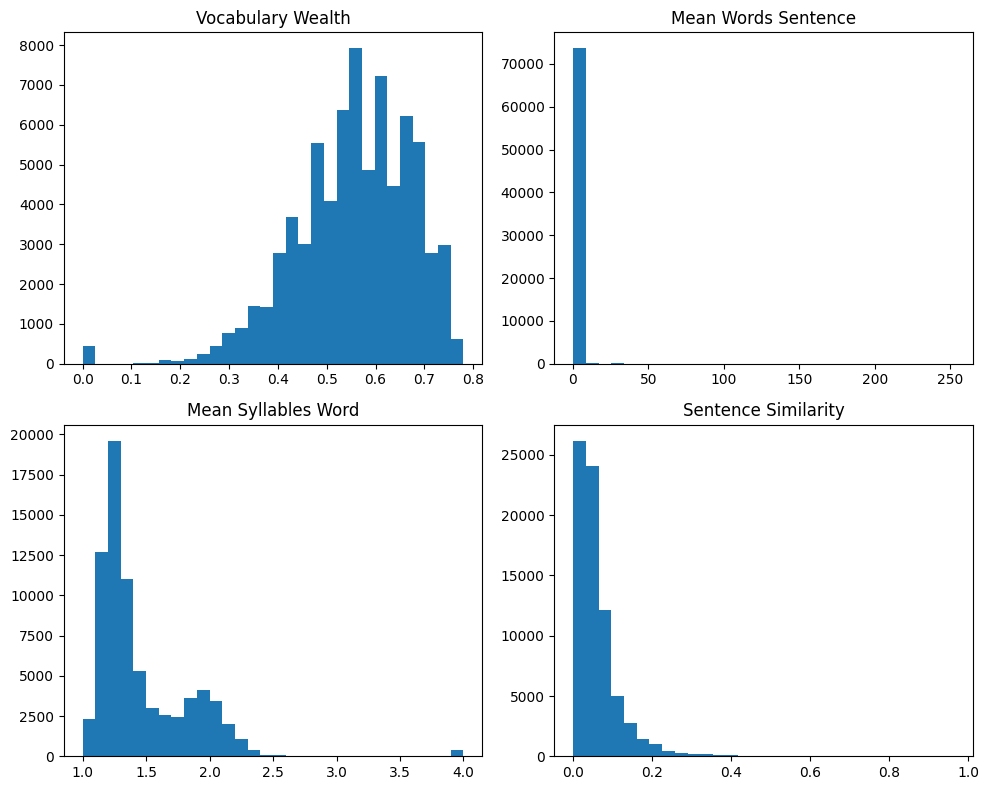

In [26]:
lyrics_features = [
    "vocabulary_wealth",
    "mean_words_sentence",
    "mean_syllables_word",
    "sentence_similarity"
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes = axes.flatten()

for i, feature in enumerate(lyrics_features):

    axes[i].hist(
        lyrics_clean[feature].dropna(),
        bins=30
    )

    axes[i].set_title(
        feature.replace("_", " ").title()
    )

plt.tight_layout()
plt.show()

### Relationships Between Lyrics Features

Correlations help identify how different aspects of lyrical complexity interact with one another.

In [27]:
lyrics_corr = lyrics_clean[
    [
        "vocabulary_wealth",
        "mean_words_sentence",
        "mean_syllables_word",
        "sentence_similarity",
        "n_sentences",
        "n_words"
    ]
].corr()

lyrics_corr

,vocabulary_wealth,mean_words_sentence,mean_syllables_word,sentence_similarity,n_sentences,n_words
vocabulary_wealth,1.000000,0.023549,0.124002,-0.465328,-0.148680,-0.086430
mean_words_sentence,0.023549,1.000000,-0.029899,-0.028082,-0.003862,0.160938
mean_syllables_word,0.124002,-0.029899,1.000000,-0.173644,-0.058376,-0.027210
sentence_similarity,-0.465328,-0.028082,-0.173644,1.000000,-0.038711,-0.045276
n_sentences,-0.148680,-0.003862,-0.058376,-0.038711,1.000000,0.682942
n_words,-0.086430,0.160938,-0.027210,-0.045276,0.682942,1.000000


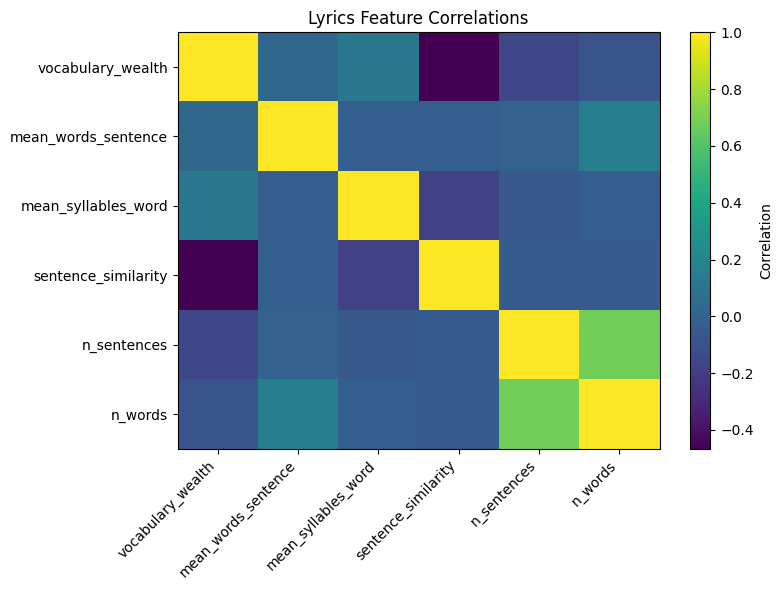

In [28]:
plt.figure(figsize=(8,6))

plt.imshow(
    lyrics_corr,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(lyrics_corr.columns)),
    lyrics_corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(lyrics_corr.index)),
    lyrics_corr.index
)

plt.title("Lyrics Feature Correlations")

plt.tight_layout()

plt.show()

### Key Observations

- Vocabulary wealth is concentrated between approximately 0.4 and 0.7, suggesting that most songs use a moderate level of lexical diversity.
- Mean syllables per word cluster around 1.2–2.0, indicating that lyrics generally rely on relatively simple vocabulary.
- Sentence similarity is heavily skewed toward low values, suggesting that many songs contain diverse lyrical content rather than highly repetitive sentence structures.
- The strongest relationship is a negative correlation between vocabulary wealth and sentence similarity (r ≈ -0.47), indicating that songs with more diverse vocabularies tend to have less repetitive lyrics.
- The number of words and number of sentences are strongly positively correlated (r ≈ 0.68), which is expected as longer lyrics naturally contain more sentences.

# 5. Feature Engineering

The cleaned datasets were transformed into numerical feature vectors suitable for similarity analysis and recommendation tasks.

## 5.1 Engineered Feature Groups

Different feature families capture different aspects of music.

Spotify features describe musical properties, lyrics features capture textual characteristics, while extracted audio features represent information directly derived from the audio signal.

In [29]:
# Define the prefixes for each feature family
group_prefixes = {
    "Chroma": "Chroma",
    "MEL": "MEL",
    "MFCC": "MFCC",
    "Spectral Contrast": "Spectral_Contrast",
    "Tonnetz": "Tonnetz",
    "Other": None  # will count anything not in the above groups
}

# Count features per group
counts = {}
for group, prefix in group_prefixes.items():
    if prefix is not None:
        counts[group] = sum(col.startswith(prefix) for col in audio_features_clean.columns)
    else:
        # Anything not matched above
        matched_cols = [col for p in group_prefixes.values() if p is not None for col in audio_features_clean.columns if col.startswith(p)]
        counts[group] = len(audio_features_clean.columns) - len(set(matched_cols))

# Create the DataFrame
feature_groups = pd.DataFrame({
    "Feature Group": list(counts.keys()),
    "Count": list(counts.values())
})

feature_groups

,Feature Group,Count
0,Chroma,12
1,MEL,128
2,MFCC,48
3,Spectral Contrast,0
4,Tonnetz,6
5,Other,14


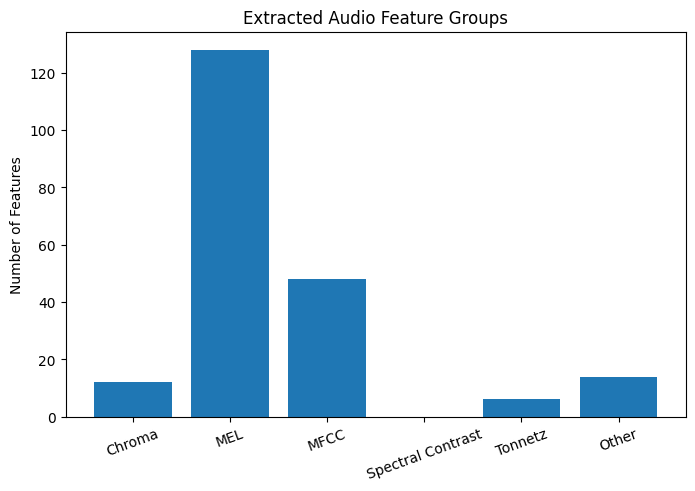

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_groups["Feature Group"],
    feature_groups["Count"]
)

plt.title("Extracted Audio Feature Groups")
plt.ylabel("Number of Features")

plt.xticks(rotation=20)

plt.show()

## 5.2 Feature Sources

Three complementary feature groups were combined:

| Feature Group | Purpose |
|---------------|----------|
| Spotify Features | Musical characteristics |
| Lyrics Features | Textual characteristics |
| Extracted Audio Features | Acoustic signal information |

Combining multiple feature types creates a richer representation of each track.

In [31]:
features_before = tracks_clean[
    [
        "danceability",
        "energy",
        "tempo",
        "acousticness",
        "popularity"
    ]
]

features_before.describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,95977.0,0.585472,0.178365,0.0,0.4750,0.607,0.718,0.989
energy,95977.0,0.600260,0.253757,0.0,0.4380,0.642,0.804,1.000
tempo,95977.0,119.423921,29.525772,0.0,97.0150,119.865,137.044,244.035
acousticness,95977.0,0.336441,0.332056,0.0,0.0358,0.212,0.610,0.996
popularity,95977.0,41.035977,16.022155,0.0,30.0000,41.000,52.000,97.000


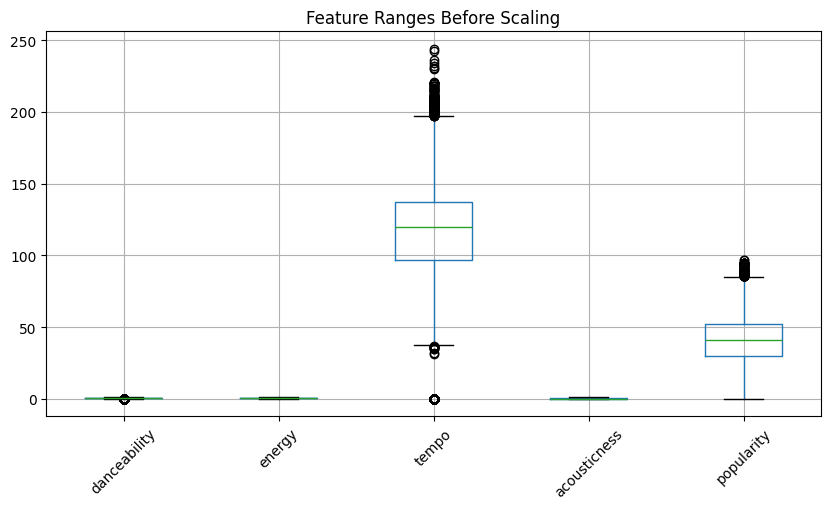

In [32]:
plt.figure(figsize=(10,5))

features_before.boxplot()

plt.title("Feature Ranges Before Scaling")

plt.xticks(rotation=45)

plt.show()

### Before Scaling

The features operate on very different numerical ranges.

Without scaling, large-valued features such as tempo or popularity would dominate similarity calculations.

## 5.3 Feature Scaling

The engineered features exist on different numerical scales.

For example:

- Danceability ranges from 0 to 1
- Tempo can exceed 200
- MFCC coefficients have very different ranges
- Lyrics features use completely different units

To ensure fair comparisons, features were normalized before similarity calculations.

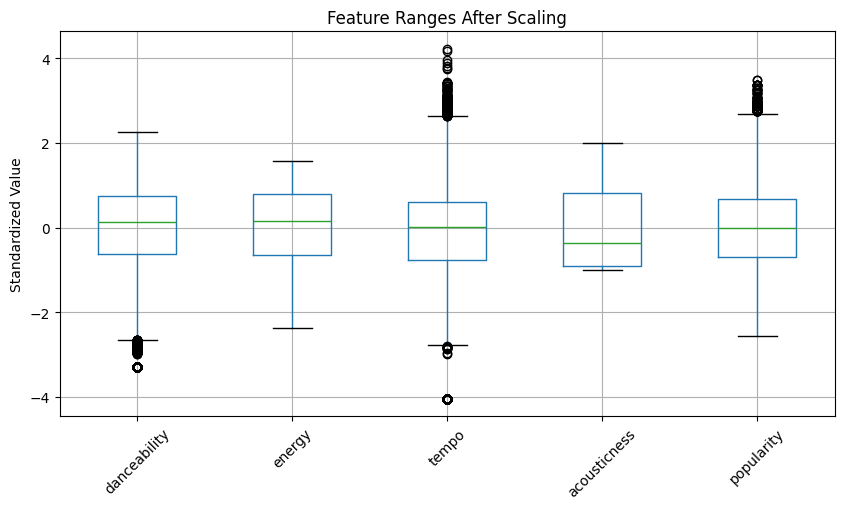

In [33]:
from sklearn.preprocessing import StandardScaler

scaling_features = [
    "danceability",
    "energy",
    "tempo",
    "acousticness",
    "popularity"
]

features_before = tracks_clean[scaling_features].copy()

scaler = StandardScaler()

features_scaled = pd.DataFrame(
    scaler.fit_transform(features_before),
    columns=scaling_features
)

plt.figure(figsize=(10,5))

features_scaled.boxplot()

plt.title("Feature Ranges After Scaling")
plt.ylabel("Standardized Value")
plt.xticks(rotation=45)

plt.show()

### Scaling Result

Before scaling, tempo and popularity operated on much larger numerical ranges than the other features.

After scaling, all features contribute more equally, preventing large-valued variables from dominating similarity calculations.

## 5.4 Final Feature Representation

Each track is represented by a combination of:

- Spotify audio features
- Lyrics-derived features
- Extracted audio signal features

This representation forms the basis for similarity analysis and recommendation tasks.

In [34]:
total_features = feature_groups["Count"].sum()

print(f"Total engineered audio features: {total_features}")

Total engineered audio features: 208


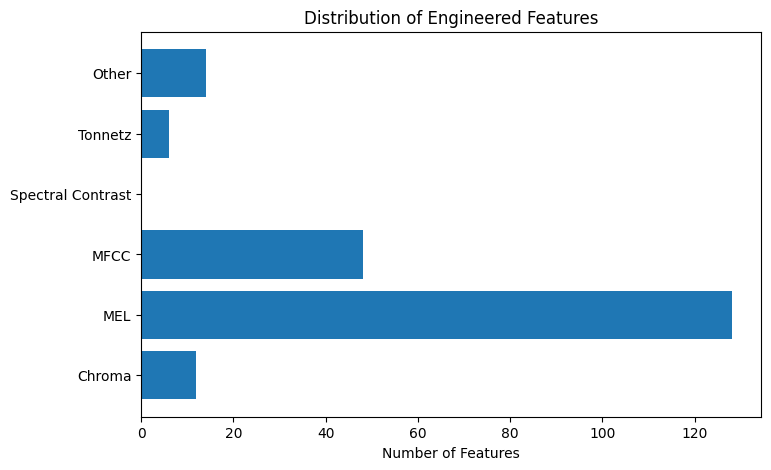

In [35]:
plt.figure(figsize=(8,5))

plt.barh(
    feature_groups["Feature Group"],
    feature_groups["Count"]
)

plt.title("Distribution of Engineered Features")
plt.xlabel("Number of Features")

plt.show()

### Key Observations

- Multiple feature families were combined to capture different aspects of music.
- Extracted audio features contributed the largest number of variables.
- Feature scaling was necessary to ensure comparability across feature groups.
- The resulting feature vectors provide a rich representation of tracks for downstream recommendation tasks.
- Spectral Contrast features were not present in the cleaned dataset, possibly due to extraction settings, but other audio feature families provide comprehensive coverage.

# 6. Project Limitations and Biases

Although extensive cleaning and preprocessing were performed, several limitations remain in the dataset and feature engineering pipeline.

### Dataset Biases

- **Popularity Bias**
  - Spotify datasets naturally contain more popular and commercially successful tracks.
  - Less mainstream music may be underrepresented.

- **Coverage Bias**
  - Not every track contains artist, album, or lyrics information.
  - Some analyses rely on subsets of the full dataset.

- **Language Bias**
  - Lyrics features are more reliable for tracks with sufficient textual content.
  - Instrumental tracks and non-English songs may be represented differently.

- **Genre Imbalance**
  - Certain genres appear substantially more often than others.
  - This can influence similarity calculations and recommendation quality.

- **Recommendation Bias**
  - Recommendations are based entirely on content similarity rather than listener preferences.
  - Songs with similar measurable characteristics may be recommended together even if listeners would not perceive them as similar.
  - The choice of features directly influences which relationships and recommendations are discovered.

### Data Quality Challenges

- Some non-musical content may still remain despite filtering.
- Spotify metadata occasionally contains incomplete or inconsistent information.
- Audio-derived features depend on the quality of the original recordings.
- Missing information cannot always be recovered automatically.

### Feature Engineering Limitations

- Feature selection was based on available metadata and extracted audio descriptors.
- Some musical characteristics cannot be fully captured through numerical features alone.
- Similar songs may still differ in aspects not represented in the feature space.

# 7. Future Work and Planned Models

The cleaned and engineered feature set provides a foundation for content-based recommendation systems.

The next project phase focuses on identifying similar tracks based on their musical, lyrical, and acoustic characteristics.

### Baseline Recommendation Model

The first recommendation approach uses:

- K-Nearest Neighbors (KNN)
- Cosine Similarity
- Scaled feature vectors

Each track is represented by its feature vector, and recommendations are generated by identifying the most similar songs in the feature space.

### Similarity Analysis

Similarity will be computed using combinations of:

- Spotify audio features
- Lyrics-derived features
- Extracted audio features

This lets us compare tracks based on multiple musical characteristics.

### Potential Extensions

Several improvements can be explored:

- Feature weighting strategies
- Hybrid combinations of feature groups
- Dimensionality reduction techniques (e.g., PCA)
- Alternative distance metrics
- Comparative evaluation of recommendation approaches

### Evaluation Strategy

Recommendation quality can be evaluated through:

- Similarity consistency
- Diversity of recommendations
- Feature-space analysis
- Qualitative inspection of recommended songs